In [1]:
import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt

from typing import Any
from feature_extractor import GeometricFeatureExtractor
from icp import ICP, SigmaAnnealingCallback, MultiStartICP, ICPCallback, fit_multi_seed
from matcher import GaussianMatcher, NearestNeighborMatcher
from utils import convergence_ratio, convergence_to_global_opt_ratio
from visualization import ErrorMetricsVisualizer, TimeVisualizer

from tabulate import tabulate

plt.style.use('seaborn-v0_8-whitegrid')

MAX_ITER = 200
N_SEEDS = 10
N_STARTS = 13

In [2]:
# 1. MultiICP with appending of geometric features in gaussian matcher
extractor = GeometricFeatureExtractor(k=4)
gaussian_matcher = GaussianMatcher(sigma=1, k=40, feature_extractor=extractor, feature_mode='append', beta=1)
callbacks: list[ICPCallback] = [SigmaAnnealingCallback(matcher=gaussian_matcher, sigma_init=4, sigma_final=0.5, anneal_steps=MAX_ITER)]
single_icp = ICP(matcher=gaussian_matcher, callbacks=callbacks, max_iter=MAX_ITER)
icp = MultiStartICP(single_icp, n_starts=N_STARTS)

# 2. MultiICP with appending of geometric features in nearest neighbor matcher
nn_matcher = NearestNeighborMatcher(feature_extractor=extractor)
nn_single_icp = ICP(matcher=nn_matcher, max_iter=MAX_ITER)
nn_icp = MultiStartICP(nn_single_icp, n_starts=N_STARTS)

In [3]:
experiment_kwargs: dict[str, Any] = {'n': 500, 'noise_std': 0.01, 't_scale': 8, 'style': 'clustered'}
ms_result1 = fit_multi_seed(icp, seeds=list(range(N_SEEDS)), experiment_kwargs=experiment_kwargs)
ms_result2 = fit_multi_seed(nn_icp, seeds=list(range(N_SEEDS)), experiment_kwargs=experiment_kwargs)

Solving 10 seeds: 100%|██████████| 10/10 [00:08<00:00,  1.22it/s]


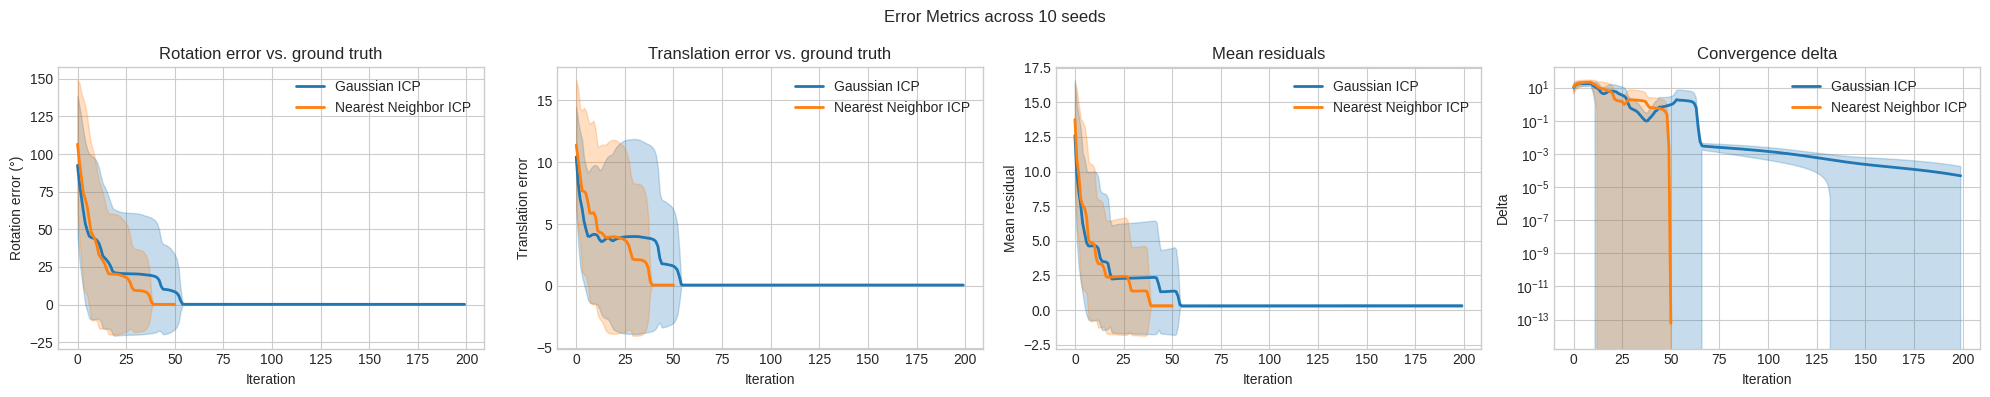

In [4]:
ErrorMetricsVisualizer.plot_convergence(
    results_per_method=[ms_result1.results, ms_result2.results], 
    ground_truths_per_method=[ms_result1.ground_truths, ms_result2.ground_truths], 
    method_labels=["Gaussian ICP", "Nearest Neighbor ICP"]
)
plt.suptitle(f"Error Metrics across {N_SEEDS} seeds")
plt.tight_layout()
plt.savefig('../results/8_rainbow_ICP_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
import numpy as np

rows: list[tuple[str, Any, Any, Any, Any]] = [
    ("Method", "Convergence Ratio", "Global Optimum Ratio", "Final Rotation Errors (°)", "Final Translation Errors"),
    ("Gaussian ICP", convergence_ratio(ms_result1.results), convergence_to_global_opt_ratio(ms_result1.results, tol=0.5), f"{np.mean(ms_result1.rotation_errors):.2f} +- {np.std(ms_result1.rotation_errors):.2f}", f"{np.mean(ms_result1.translation_errors):.2f} +- {np.std(ms_result1.translation_errors):.2f}"),
    ("Nearest Neighbor ICP", convergence_ratio(ms_result2.results), convergence_to_global_opt_ratio(ms_result2.results, tol=0.5), f"{np.mean(ms_result2.rotation_errors):.2f} +- {np.std(ms_result2.rotation_errors):.2f}", f"{np.mean(ms_result2.translation_errors):.2f} +- {np.std(ms_result2.translation_errors):.2f}"),
]

print(tabulate(rows, headers="firstrow", tablefmt="rounded_grid", floatfmt=".4f"))

╭──────────────────────┬─────────────────────┬────────────────────────┬─────────────────────────────┬────────────────────────────╮
│ Method               │   Convergence Ratio │   Global Optimum Ratio │ Final Rotation Errors (°)   │ Final Translation Errors   │
├──────────────────────┼─────────────────────┼────────────────────────┼─────────────────────────────┼────────────────────────────┤
│ Gaussian ICP         │              0.8000 │                 0.9000 │ 0.16 +- 0.10                │ 0.07 +- 0.03               │
├──────────────────────┼─────────────────────┼────────────────────────┼─────────────────────────────┼────────────────────────────┤
│ Nearest Neighbor ICP │              1.0000 │                 0.9000 │ 0.16 +- 0.10                │ 0.07 +- 0.03               │
╰──────────────────────┴─────────────────────┴────────────────────────┴─────────────────────────────┴────────────────────────────╯


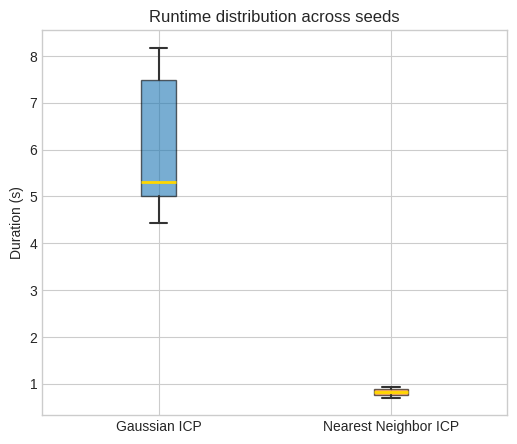

In [6]:
fix, axes = plt.subplots(1, 1, figsize=(6, 5))

TimeVisualizer.plot_duration_distribution(
    ax=axes,
    durations_per_method=[np.array(ms_result1.durations_s), np.array(ms_result2.durations_s)], 
    method_labels=["Gaussian ICP", "Nearest Neighbor ICP"]
    )
plt.show()